# Test STOP rules — diseño z→angle→time

Verifica:
- **STOP-A** (z-loop): mantiene un contador de redshifts consecutivos sin detección en ningún `(angle, time)`. Si el contador alcanza `z_patience` → no computar `z` mayores.
- **STOP-LC** per-banda: dentro de cada `(z, angle)`, cada banda corta tras `lc_patience` no-detecciones consecutivas **en decay**; el time-loop se trunca cuando todas las bandas cortaron.

Dust (Av, Rv, EBV) se sortea **una vez por z** y se reutiliza entre todos los ángulos a ese z (host fijo por redshift). En vez de los 50 ángulos del cubo se **samplean N_TEST_ANGLES (=5) índices aleatorios**; si esos 5 no detectan a `z_patience` redshifts consecutivos, STOP-A descarta los `z` mayores.

In [106]:
import sys
import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))
from generate_extinguished_spectra import (
    load_roman_filters, build_redshift_grid, DEFAULT_KCOR_PATH,
    sample_extinction_av, sample_extinction_rv,
)

SPECTRA_PATH  = Path('lanl_spectra.parquet')
KCOR_PATH     = DEFAULT_KCOR_PATH

# Límite de detección imagin sensityivy overveiw
MAG_LIMITS = {
    'R062-R': 28,
    'Z087-Z': 28,
    'Y106-Y': 28,  
    'J129-J': 28,  
    'H158-H': 28,   
    'F184-F': 28,  
    'K213-K': 28,  
}
LC_PATIENCE     = 3
Z_PATIENCE      = 3     # STOP-A: # de z consecutivos sin detección para cortar
RANDOM_SEED     = 42
ROW_GROUP       = 0
N_TEST_ANGLES   = 5     # ángulos sampleados aleatoriamente del cubo

Z_GRID = build_redshift_grid(0.003, 0.5, 12, 'log')
z_min  = float(np.sort(Z_GRID)[0])
print('z grid:', np.round(Z_GRID, 4))
print('z_min :', round(z_min, 5))

z grid: [0.003  0.0048 0.0076 0.0121 0.0193 0.0307 0.0489 0.0778 0.1239 0.1972
 0.314  0.5   ]
z_min : 0.003


In [107]:
np.random.seed(RANDOM_SEED)
av_pool  = sample_extinction_av(5000)
rv_pool  = sample_extinction_rv(5000)
ebv_pool = np.full(5000, 0.03)

roman_filters = load_roman_filters(KCOR_PATH)
filter_names  = list(roman_filters.keys())

# Array de límites alineado con filter_names (shape: n_filters)
missing = [fn for fn in filter_names if fn not in MAG_LIMITS]
if missing:
    raise ValueError(f'MAG_LIMITS faltante para bandas: {missing}')
mag_limit_arr = np.array([MAG_LIMITS[fn] for fn in filter_names], dtype=float)
print('mag limits:', dict(zip(filter_names, mag_limit_arr)))

pf     = pq.ParquetFile(SPECTRA_PATH)
lam_aa = np.frombuffer(
    pf.schema_arrow.metadata[b'wavelength_rest_aa'], dtype=np.float32
).astype(np.float64)

df_full = pf.read_row_group(ROW_GROUP).to_pandas()

# Sampleo aleatorio de N_TEST_ANGLES índices únicos del set de ángulos disponibles
all_angles  = np.sort(df_full['angle_index'].unique())
rng_angles  = np.random.default_rng(RANDOM_SEED)
n_pick      = min(N_TEST_ANGLES, len(all_angles))
TEST_ANGLES = sorted(int(a) for a in rng_angles.choice(all_angles, size=n_pick, replace=False))
print(f'Ángulos disponibles: {len(all_angles)}  →  sampleados: {TEST_ANGLES}')

df_in = df_full[df_full['angle_index'].isin(TEST_ANGLES)].copy()
print(f'Filas a procesar: {len(df_in)}  '
      f'(ángulos {TEST_ANGLES}, {df_in["time_index"].nunique()} pasos de tiempo)')

mag limits: {'R062-R': np.float64(28.0), 'Z087-Z': np.float64(28.0), 'Y106-Y': np.float64(28.0), 'J129-J': np.float64(28.0), 'H158-H': np.float64(28.0), 'F184-F': np.float64(28.0)}
Ángulos disponibles: 54  →  sampleados: [4, 23, 34, 39, 53]
Filas a procesar: 350  (ángulos [4, 23, 34, 39, 53], 70 pasos de tiempo)


## Función de procesamiento común

Una sola función que acepta `stop_a` y `stop_lc` como flags para poder comparar los dos modos.

In [108]:
from dust_extinction.parameter_averages import F99
from astropy.cosmology import Planck18
from astropy import units as u
import pyphot

F99_VALID = (1000.0, 33333.0)
MILKY_WAY_RV = 3.1


def _presample_dust(z_grid, av_pool, rv_pool, ebv_pool, seed):
    """One dust draw per redshift, shared across all angles at that z."""
    n_z = len(z_grid)
    rng = np.random.default_rng(seed)
    av_arr  = rng.choice(av_pool,  size=n_z)
    rv_arr  = rng.choice(rv_pool,  size=n_z)
    ebv_arr = rng.choice(ebv_pool, size=n_z)
    return av_arr, rv_arr, ebv_arr


def _transmission(wl_aa, av, rv):
    """F99 transmission curve; ones outside valid range."""
    model = F99(Rv=float(rv))
    t = np.ones(len(wl_aa))
    mask = (wl_aa >= F99_VALID[0]) & (wl_aa <= F99_VALID[1])
    if mask.any():
        t[mask] = model.extinguish(wl_aa[mask] * u.AA, Av=float(av))
    return t


def _mags_batch(wl_obs_aa, flux_matrix, roman_filters):
    """Batch AB magnitudes.

    Parameters
    ----------
    wl_obs_aa  : (n_wl,)
    flux_matrix: (n_t, n_wl)  f_lambda  [erg/s/cm²/Å]

    Returns
    -------
    mags : (n_t, n_filters)  AB mag, NaN where unphysical
    """
    wl_u   = wl_obs_aa * pyphot.config.units.U('AA')
    flux_u = flux_matrix * pyphot.config.units.U('flam')
    n_t = flux_matrix.shape[0]
    mags = np.full((n_t, len(roman_filters)), np.nan)
    for f_idx, (_fn, fd) in enumerate(roman_filters.items()):
        pf = fd['filter']
        fnu  = pf.get_flux(wl_u, flux_u, axis=-1)
        fval = np.asarray(getattr(fnu, 'magnitude', fnu.value), dtype=float).ravel()
        good = (fval > 0) & np.isfinite(fval)
        mags[good, f_idx] = -2.5 * np.log10(fval[good]) - pf.AB_zero_mag
    return mags


def _lc_stop_idx_perband(mags, mag_limit, patience):
    """First index past which to stop; keeps mags[:result].

    Per-band rule: each band b maintains a counter of consecutive
    non-detected steps in decay. Stop fires when ALL bands have
    count >= patience.

    Decay between consecutive steps for band b:
        finite prev, finite curr -> in_decay iff curr > prev (fainter)
        finite prev, NaN  curr   -> in_decay (band dropped off)
        NaN   prev, finite curr  -> NOT in_decay (band came online)
        NaN   prev, NaN   curr   -> in_decay (stayed off)
    Detected steps reset the counter for that band. Step 0 cannot be
    in decay (no previous reference).
    """
    n_t, n_f = mags.shape
    count = np.zeros(n_f, dtype=int)
    prev  = np.full(n_f, np.nan)
    for i in range(n_t):
        curr = mags[i]
        if i == 0:
            prev = curr
            continue
        detected_b = np.isfinite(curr) & (curr <= mag_limit)
        fp, fc = np.isfinite(prev), np.isfinite(curr)
        in_decay = np.where(
            fp & fc, curr > prev,
            np.where(fp & ~fc, True,
                     np.where(~fp & fc, False, True))
        )
        advance = (~detected_b) & in_decay
        count = np.where(detected_b, 0,
                np.where(advance, count + 1, count))
        prev = curr
        if (count >= patience).all():
            return i + 1
    return n_t


def run_pipeline(df, lam_aa, av_arr, rv_arr, ebv_arr,
                 roman_filters, z_grid, mag_limit, lc_patience,
                 z_patience=3, stop_a=True, stop_lc=True):
    """Loop: redshift (near→far) → angle → time (vectorised batch).

    Dust is fixed per redshift, shared across all angles at that z.
    STOP-LC: per-band decay rule within each (z, angle).
    STOP-A : tracks consecutive redshifts with no detection across any
             (angle, time). When the streak reaches `z_patience`, break
             the z-loop. A detection at any z resets the counter.
    """
    z_sorted = np.sort(np.asarray(z_grid, dtype=float))
    fn_list  = list(roman_filters.keys())
    angles   = sorted(df['angle_index'].unique())

    lum_dist_pc = Planck18.luminosity_distance(z_sorted).to(u.pc).value
    lum_dist_pc = np.where(z_sorted > 0, lum_dist_pc, 10.0)

    # Pre-extract per-angle (t_indices, t_days, flux_mat).
    per_angle = {}
    for angle_index in angles:
        group = (df[df['angle_index'] == angle_index]
                 .sort_values('time_index').reset_index(drop=True))
        per_angle[angle_index] = dict(
            t_indices = group['time_index'].values.astype(int),
            t_days    = group['time_days'].values.astype(float),
            flux_mat  = np.maximum(
                np.array(group['flux_rest'].tolist(), dtype=np.float64), 0.0
            ),
        )

    blocks = []
    z_miss_streak = 0

    for z_idx, z in enumerate(z_sorted):
        av  = float(av_arr[z_idx])
        rv  = float(rv_arr[z_idx])
        ebv = float(ebv_arr[z_idx])

        # Transmission curves depend only on z and dust → compute once per z.
        trans_host = _transmission(lam_aa, av, rv)                  # (n_wl,)
        wl_obs     = lam_aa * (1.0 + float(z))                      # (n_wl,)
        av_mw      = MILKY_WAY_RV * ebv
        trans_mw   = _transmission(wl_obs, av_mw, MILKY_WAY_RV)     # (n_wl,)
        dim        = (10.0 / lum_dist_pc[z_idx]) ** 2

        any_detected_at_z = False

        for angle_index in angles:
            data = per_angle[angle_index]
            flux_obs = (data['flux_mat'] * trans_host
                        * (dim / (1.0 + float(z))) * trans_mw)        # (n_t, n_wl)

            mags     = _mags_batch(wl_obs, flux_obs, roman_filters)   # (n_t, n_f)
            detected = np.any(mags <= mag_limit, axis=1)               # (n_t,) bool

            stop_idx = (_lc_stop_idx_perband(mags, mag_limit, lc_patience)
                        if stop_lc else len(detected))

            if detected[:stop_idx].any():
                any_detected_at_z = True

            n = stop_idx
            if n == 0:
                continue
            block = {
                'time_index':    data['t_indices'][:n].astype(int),
                'time_days':     data['t_days'][:n],
                'angle_index':   np.full(n, int(angle_index), dtype=int),
                'redshift':      np.full(n, float(z)),
                'av_host':       np.full(n, av),
                'rv_host':       np.full(n, rv),
                'ebv_milky_way': np.full(n, ebv),
                'detected':      detected[:n].astype(bool),
                'lum_dist_pc':   np.full(n, float(lum_dist_pc[z_idx])),
            }
            for f_idx, fn in enumerate(fn_list):
                block[f'mag_{fn}'] = mags[:n, f_idx].astype(float)
            blocks.append(pd.DataFrame(block))

        # STOP-A: contador de z consecutivos sin detección.
        # Detección a cualquier z resetea; al alcanzar z_patience se corta.
        if stop_a:
            if any_detected_at_z:
                z_miss_streak = 0
            else:
                z_miss_streak += 1
                if z_miss_streak >= z_patience:
                    break

    if not blocks:
        cols = (['time_index', 'time_days', 'angle_index', 'redshift',
                 'av_host', 'rv_host', 'ebv_milky_way', 'detected', 'lum_dist_pc']
                + [f'mag_{fn}' for fn in fn_list])
        return pd.DataFrame(columns=cols)
    return pd.concat(blocks, ignore_index=True)

In [109]:
SEED = RANDOM_SEED * 1_000_003 + ROW_GROUP

av_arr, rv_arr, ebv_arr = _presample_dust(
    Z_GRID, av_pool, rv_pool, ebv_pool, SEED)

kw = dict(lam_aa=lam_aa, av_arr=av_arr, rv_arr=rv_arr, ebv_arr=ebv_arr,
          roman_filters=roman_filters, z_grid=Z_GRID,
          mag_limit=mag_limit_arr, lc_patience=LC_PATIENCE,
          z_patience=Z_PATIENCE)

print('Corriendo CON STOP...')
df_stop = run_pipeline(df_in, **kw, stop_a=True, stop_lc=True)
print(f'  {len(df_stop)} filas')

print('Corriendo SIN STOP (referencia)...')
df_ref = run_pipeline(df_in, **kw, stop_a=False, stop_lc=False)
print(f'  {len(df_ref)} filas')

pct = 100 * (1 - len(df_stop) / len(df_ref))
print(f'\nAhorro STOP: {len(df_ref) - len(df_stop):,} filas ({pct:.1f}%)')

Corriendo CON STOP...
  2123 filas
Corriendo SIN STOP (referencia)...
  4200 filas

Ahorro STOP: 2,077 filas (49.5%)


## Test de integridad: las filas comunes son idénticas

In [110]:
KEY  = ['angle_index', 'time_index', 'redshift']
VALS = ['av_host', 'rv_host', 'detected'] + [f'mag_{fn}' for fn in filter_names]

merged = df_stop[KEY + VALS].merge(df_ref[KEY + VALS], on=KEY, suffixes=('_s', '_r'))
print(f'Filas matcheadas: {len(merged)} / {len(df_stop)}')

ok = True
for col in VALS:
    s, r = merged[f'{col}_s'], merged[f'{col}_r']
    if s.dtype == bool:
        n = (s != r).sum()
    else:
        n = (~np.isclose(s.astype(float), r.astype(float), equal_nan=True)).sum()
    if n:
        print(f'  MISMATCH {col}: {n} filas')
        ok = False

print('Integridad:', '✓ PASS — valores idénticos' if ok else '✗ FAIL')

Filas matcheadas: 2123 / 2123
Integridad: ✓ PASS — valores idénticos


## Test STOP-A: los z omitidos están siempre *después* del corte

In [111]:
# STOP-A (z global con patience): si hubo corte, los Z_PATIENCE z computados
# más altos no deben tener detección en ningún (angle, time); y los z faltantes
# deben ser todos > z_max_done.
issues_a = []
z_computed = sorted(df_stop['redshift'].unique())
z_ref      = sorted(df_ref['redshift'].unique())

if z_computed:
    z_max_done = max(z_computed)
    # Ningún z < z_max_done puede estar omitido (z-loop es monótono).
    missing_below = [z for z in z_ref
                     if z < z_max_done - 1e-10 and not any(
                         np.isclose(z, zc) for zc in z_computed)]
    if missing_below:
        issues_a.append(('missing_below_max', missing_below))

    # Si hubo corte: las últimas Z_PATIENCE z computadas deben ser todas
    # sin detección (esa es la racha que disparó el break).
    if z_max_done < max(z_ref) - 1e-10:
        tail = z_computed[-Z_PATIENCE:]
        if len(tail) < Z_PATIENCE:
            issues_a.append(('tail_shorter_than_patience', tail))
        else:
            for zt in tail:
                sub = df_stop[np.isclose(df_stop['redshift'], zt)]
                if sub['detected'].any():
                    issues_a.append(('detection_in_stop_tail', float(zt)))

print(f'Z_PATIENCE = {Z_PATIENCE}')
print(f'z computados: {len(z_computed)} / {len(z_ref)}')
print('STOP-A:', '✓ PASS' if not issues_a else f'✗ FAIL: {issues_a}')

Z_PATIENCE = 3
z computados: 10 / 12
STOP-A: ✓ PASS


## Test STOP-LC: los pasos de tiempo omitidos cumplen la condición

In [112]:
# STOP-LC per-banda: verificación canónica.
# En cada (angle, z) truncado, re-ejecutamos _lc_stop_idx_perband sobre
# la serie completa de mags (df_ref) y debe devolver exactamente la
# longitud que quedó en df_stop. Esto valida la regla real (contador
# por banda con reset sólo en detección), incluyendo pasos "stay"
# (nondet & ~in_decay) que mantienen el contador.
issues_lc = []
mag_cols_local = [f'mag_{fn}' for fn in filter_names]

n_truncated = 0
for (ai, z), grp_stop in df_stop.groupby(['angle_index', 'redshift']):
    grp_ref = df_ref[
        (df_ref['angle_index'] == ai) & np.isclose(df_ref['redshift'], z)
    ].sort_values('time_index').reset_index(drop=True)

    if len(grp_stop) >= len(grp_ref):
        continue
    n_truncated += 1

    mags_full = grp_ref[mag_cols_local].to_numpy(dtype=float)
    expected_len = _lc_stop_idx_perband(mags_full, mag_limit_arr, LC_PATIENCE)
    if expected_len != len(grp_stop):
        issues_lc.append((int(ai), float(z), int(expected_len), int(len(grp_stop))))

print(f'Pares (ángulo, z) truncados por STOP-LC: {n_truncated}')
print('STOP-LC:', '✓ PASS' if not issues_lc else f'✗ FAIL ({len(issues_lc)} casos: {issues_lc[:3]})')

Pares (ángulo, z) truncados por STOP-LC: 50
STOP-LC: ✓ PASS


## Visualización: cobertura y curvas de luz

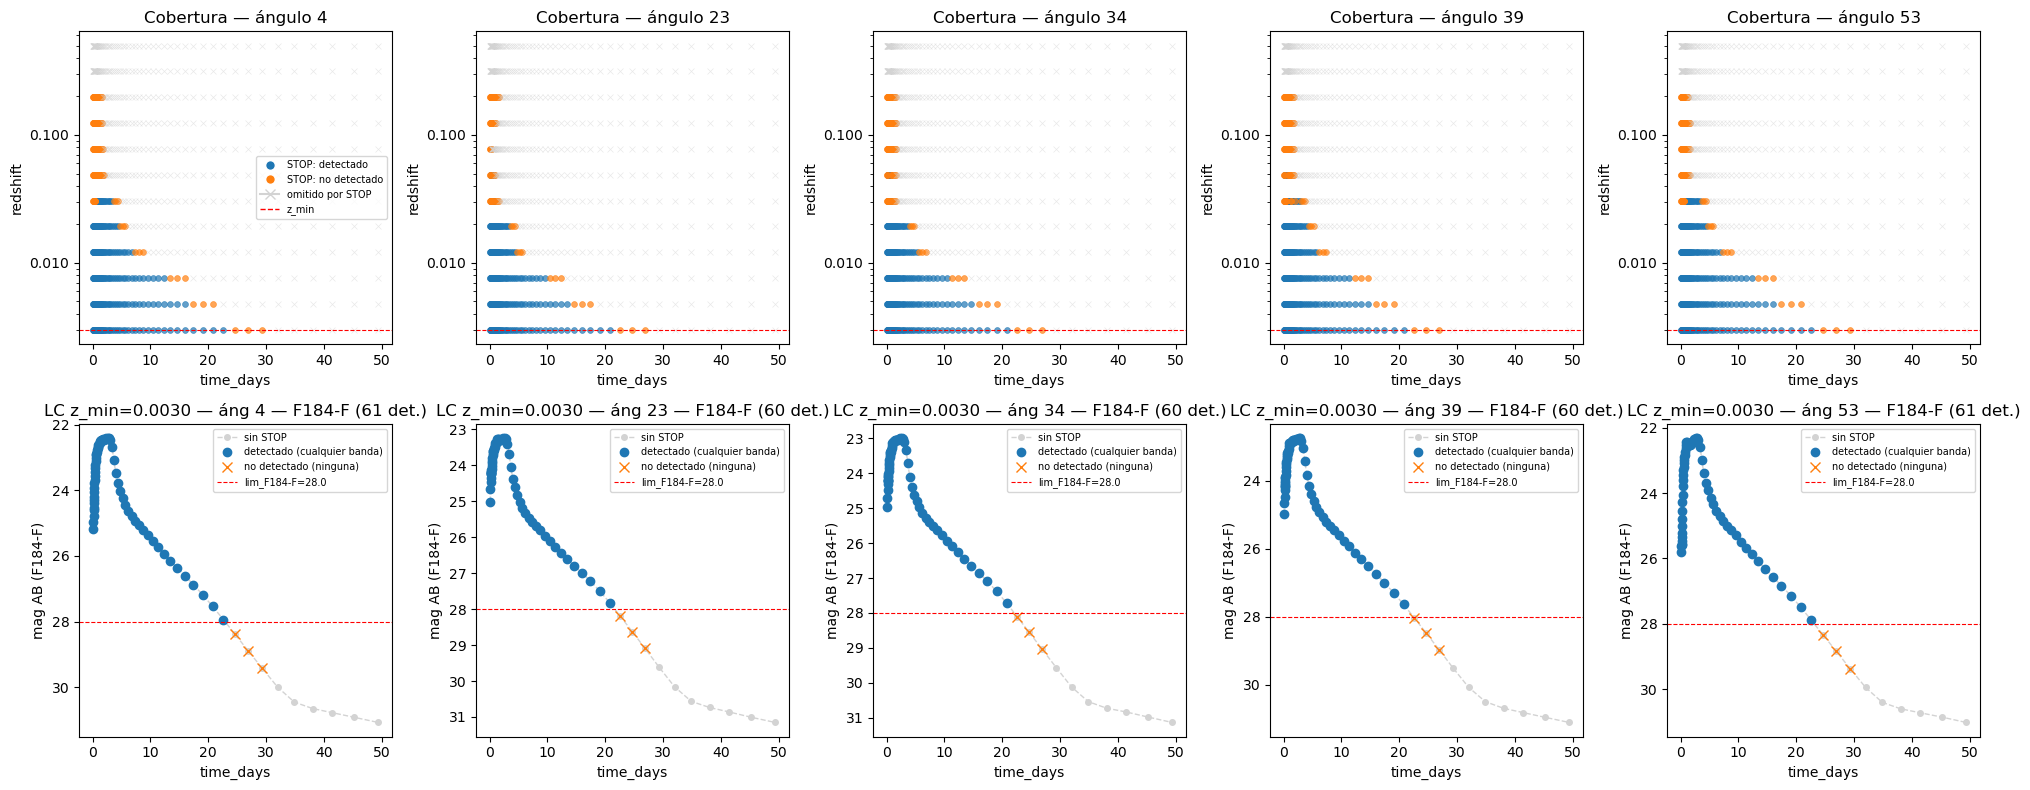

In [113]:
mag_cols = [f'mag_{fn}' for fn in filter_names]

n_cols = len(TEST_ANGLES)
fig, axes = plt.subplots(2, n_cols, figsize=(max(6, 4 * n_cols), 8), squeeze=False)

for col_idx, angle in enumerate(TEST_ANGLES):
    # --- fila superior: mapa (time_days, redshift) ---
    ax_map = axes[0, col_idx]
    sub_ref  = df_ref[df_ref['angle_index'] == angle]
    sub_stop = df_stop[df_stop['angle_index'] == angle]

    # Clasificación vectorizada: in_stop ∧ detected | in_stop ∧ ¬detected | ¬in_stop
    stop_keys = pd.MultiIndex.from_arrays(
        [sub_stop['time_index'].values, sub_stop['redshift'].values])
    ref_keys  = pd.MultiIndex.from_arrays(
        [sub_ref['time_index'].values,  sub_ref['redshift'].values])
    in_stop   = ref_keys.isin(stop_keys)
    det       = sub_ref['detected'].values.astype(bool)
    td, zd    = sub_ref['time_days'].values, sub_ref['redshift'].values

    m_blue   = in_stop &  det
    m_orange = in_stop & ~det
    m_gray   = ~in_stop
    ax_map.scatter(td[m_blue],   zd[m_blue],   c='tab:blue',   marker='o', s=18, alpha=0.7, linewidths=0.5)
    ax_map.scatter(td[m_orange], zd[m_orange], c='tab:orange', marker='o', s=18, alpha=0.7, linewidths=0.5)
    ax_map.scatter(td[m_gray],   zd[m_gray],   c='lightgray',  marker='x', s=18, alpha=0.5, linewidths=0.5)

    ax_map.axhline(z_min, color='red', lw=0.8, ls='--')
    ax_map.set_yscale('log')
    ax_map.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax_map.set_xlabel('time_days')
    ax_map.set_ylabel('redshift')
    ax_map.set_title(f'Cobertura — ángulo {angle}')

    # --- fila inferior: curva de luz a z_min, banda más detectada ---
    ax_lc = axes[1, col_idx]
    s_ref  = sub_ref[np.isclose(sub_ref['redshift'], z_min)].sort_values('time_days')
    s_stop = sub_stop[np.isclose(sub_stop['redshift'], z_min)].sort_values('time_days')

    # banda con más timesteps detectados en df_ref a z_min (vectorizado)
    mags_ref   = s_ref[mag_cols].to_numpy(dtype=float)         # (n_t, n_f)
    det_counts = np.sum(np.isfinite(mags_ref) & (mags_ref <= mag_limit_arr), axis=0)
    best_idx   = int(np.argmax(det_counts))
    best_fn    = filter_names[best_idx]
    best_col   = f'mag_{best_fn}'
    best_lim   = float(mag_limit_arr[best_idx])

    ax_lc.plot(s_ref['time_days'], s_ref[best_col], 'o--', c='lightgray', ms=4, lw=1, label='sin STOP')
    if len(s_stop) > 0:
        det  = s_stop[s_stop['detected']]
        ndet = s_stop[~s_stop['detected']]
        if len(det)  > 0: ax_lc.plot(det['time_days'],  det[best_col],  'o', c='tab:blue',   ms=6, label='detectado (cualquier banda)')
        if len(ndet) > 0: ax_lc.plot(ndet['time_days'], ndet[best_col], 'x', c='tab:orange', ms=7, label='no detectado (ninguna)')
    ax_lc.axhline(best_lim, color='red', ls='--', lw=0.8, label=f'lim_{best_fn}={best_lim}')
    ax_lc.invert_yaxis()
    ax_lc.set_xlabel('time_days')
    ax_lc.set_ylabel(f'mag AB ({best_fn})')
    ax_lc.set_title(f'LC z_min={z_min:.4f} — áng {angle} — {best_fn} ({det_counts[best_idx]} det.)')
    ax_lc.legend(fontsize=7)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:blue',   ms=7, label='STOP: detectado'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='tab:orange', ms=7, label='STOP: no detectado'),
    Line2D([0],[0], marker='x', color='lightgray', ms=7, label='omitido por STOP'),
    Line2D([0],[0], color='red', ls='--', lw=1, label='z_min'),
]
axes[0, 0].legend(handles=legend_elements, fontsize=7)

plt.tight_layout()
plt.savefig('stop_rules_test.png', dpi=150)
plt.show()

In [ ]:
print('='*55)
print('RESUMEN')
print('='*55)
print(f'LC patience      : {LC_PATIENCE} pasos consecutivos no detect. en decay')
print(f'Z  patience      : {Z_PATIENCE} z consecutivos sin detección')
print(f'Filas sin STOP   : {len(df_ref):,}')
print(f'Filas con STOP   : {len(df_stop):,}  (ahorro {pct:.1f}%)')
print(f'Integridad       : {"PASS" if ok else "FAIL"}')
print(f'STOP-A           : {"PASS" if not issues_a else f"FAIL ({len(issues_a)})"}')
print(f'STOP-LC          : {"PASS" if not issues_lc else f"FAIL ({len(issues_lc)})"}')
print('='*55)